# Thai Vowel Classification — CNN + MFCC

## Section 1 — Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive


In [2]:
# ── Constants ───────────────────────────────────────────────
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_CLASSES   = 18
EPOCHS      = 100
BATCH_SIZE  = 32
RANDOM_SEED = 42
N_FOLDS     = 5

VOWEL_LABELS = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

# ── Fix Random Seed ─────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Random seed fixed: {RANDOM_SEED}')

Random seed fixed: 42


## Section 2 — Load Dataset

In [3]:
base_path = r'/content/drive/My Drive/dataset'

data = []
for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                data.append([os.path.join(folder, file), label])

df = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total samples : {len(df)}')
print(df['label'].value_counts())

Total samples : 1800
label
s4    100
s7    100
s8    100
s9    100
s2    100
s6    100
s5    100
s3    100
s1    100
09    100
08    100
06    100
07    100
03    100
05    100
04    100
02    100
01    100
Name: count, dtype: int64


## Section 3 — Preprocessing Functions

In [4]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):

    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):

    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound, silence_threshold)
    end   = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start : len(sound) - end]

    if len(trimmed) == 0:
        trimmed = sound

    chunk_ms  = 10
    energies  = [trimmed[i:i+chunk_ms].rms for i in range(0, len(trimmed), chunk_ms)]
    peak_idx  = int(np.argmax(energies))
    peak_ms   = peak_idx * chunk_ms

    half       = window_ms // 2
    crop_start = max(0, peak_ms - half)
    crop_end   = min(len(trimmed), crop_start + window_ms)
    final      = trimmed[crop_start:crop_end]

    out_path = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out_path, format='wav')
    return out_path

## Section 4 — Feature Extraction (MFCC + delta + delta²)

In [5]:
def extract_mfcc(file_path, max_len=18):

    wave, _ = librosa.load(file_path, mono=True, sr=SR)

    mfcc = librosa.feature.mfcc(y=wave, sr=SR,n_fft=N_FFT, hop_length=HOP_LENGTH)
    if mfcc.shape[1] < 9:
        mfcc = np.pad(mfcc, ((0,0),(0, 9 - mfcc.shape[1])), mode='edge')

    delta  = librosa.feature.delta(mfcc, mode='nearest')
    delta2 = librosa.feature.delta(mfcc, order=2, mode='nearest')
    feat   = np.vstack([mfcc, delta, delta2])  # (n_mfcc*3, T)

    if feat.shape[1] < max_len:
        feat = np.pad(feat, ((0,0),(0, max_len - feat.shape[1])), mode='constant')
    else:
        feat = feat[:, :max_len]

    # Per-sample normalization → stable gradient across all folds
    feat = (feat - feat.mean()) / (feat.std() + 1e-6)

    return feat  # (n_mfcc*3, max_len)

In [6]:
# ── Debug: ดู range ก่อน/หลัง normalize จากไฟล์ตัวอย่าง ──
sample_path = df['file_path'].iloc[0]
wave, _ = librosa.load(sample_path, mono=True, sr=SR)
mfcc = librosa.feature.mfcc(y=wave, sr=SR, n_mfcc=20, n_fft=N_FFT, hop_length=HOP_LENGTH)
delta = librosa.feature.delta(mfcc, mode='nearest')
delta2 = librosa.feature.delta(mfcc, order=2, mode='nearest')
feat_raw = np.vstack([mfcc, delta, delta2])

print('── ก่อน normalize ──')
print(f'  Max: {feat_raw.max():.4f}  Min: {feat_raw.min():.4f}')
print(f'  Mean: {feat_raw.mean():.4f}  Std: {feat_raw.std():.4f}')

feat_norm = (feat_raw - feat_raw.mean()) / (feat_raw.std() + 1e-6)

print('\n── หลัง normalize ──')
print(f'  Max: {feat_norm.max():.4f}  Min: {feat_norm.min():.4f}')
print(f'  Mean: {feat_norm.mean():.4f}  Std: {feat_norm.std():.4f}')

── ก่อน normalize ──
  Max: 142.4043  Min: -136.5668
  Mean: -1.0318  Std: 26.9962

── หลัง normalize ──
  Max: 5.3132  Min: -5.0205
  Mean: 0.0000  Std: 1.0000


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1953
  warnings.warn(


## Section 5 — Dataset Analysis (duration percentiles)

Run once to justify MAX_LEN choice.

In [7]:
durations = []
for fp in tqdm(df['file_path'], desc='Measuring durations'):
    y, _ = librosa.load(fp, sr=SR)
    durations.append(len(y) / SR)

durations = np.array(durations)
print('Duration stats (seconds):')
for p in [25, 50, 75, 90, 95]:
    frames = int(np.percentile(durations, p) * SR / HOP_LENGTH)
    print(f'  p{p}: {np.percentile(durations, p):.3f}s → {frames} frames')

Measuring durations: 100%|██████████| 1800/1800 [09:15<00:00,  3.24it/s]

Duration stats (seconds):
  p25: 0.123s → 3 frames
  p50: 0.226s → 7 frames
  p75: 0.375s → 11 frames
  p90: 0.491s → 15 frames
  p95: 0.576s → 18 frames


## Section 6 — Build Full Dataset

In [9]:
PROC_DIR = '/content/proc_smartcrop'
MAX_LEN  = 18  # p95 from duration analysis

processed_paths = [
    smart_crop(fp, PROC_DIR)
    for fp in tqdm(df['file_path'], desc='smart_crop')
]

X = np.array([
    extract_mfcc(p, max_len=MAX_LEN)
    for p in tqdm(processed_paths, desc='MFCC extraction')
])  # (N, n_mfcc*3, MAX_LEN)

le    = LabelEncoder()
y_int = le.fit_transform(df['label'])

print(f'X shape : {X.shape}')
print(f'Classes : {le.classes_}')

MFCC extraction:   0%|          | 0/1800 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1952
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1776
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1440
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1808
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1472
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1552
  warnings.warn(
/usr/lo

X shape : (1800, 60, 18)
Classes : ['01' '02' '03' '04' '05' '06' '07' '08' '09' 's1' 's2' 's3' 's4' 's5'
 's6' 's7' 's8' 's9']


## Section 7 — Hold-Out Test Split (10%)

In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_int,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_int
)

print(f'Train+Val : {X_trainval.shape[0]} samples')
print(f'Test      : {X_test.shape[0]} samples')

Train+Val : 1620 samples
Test      : 180 samples


## Section 8 — Model Architecture (CNN)

In [11]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (2,2), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (2,2), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(N_CLASSES, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dummy = build_model((X_trainval.shape[1], X_trainval.shape[2], 1))
dummy.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 18, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 9, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 9, 64)      │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17280)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115,570 (4.26 MB)

 Trainable params: 1,115,570 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

## Section 9 — Stratified 5-Fold Cross-Validation

In [12]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []

X_tv = X_trainval[..., np.newaxis]  # add channel dim

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f'\n── Fold {fold}/{N_FOLDS} ──')

    random.seed(RANDOM_SEED * fold)
    np.random.seed(RANDOM_SEED * fold)
    tf.random.set_seed(RANDOM_SEED * fold)

    X_tr,  X_val  = X_tv[tr_idx],      X_tv[val_idx]
    y_tr,  y_val  = y_trainval[tr_idx], y_trainval[val_idx]

    y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
    y_val_cat = to_categorical(y_val, N_CLASSES)

    model = build_model(X_tr.shape[1:])
    es    = EarlyStopping(monitor='val_loss', patience=15,
                          restore_best_weights=True, verbose=0)

    model.fit(
        X_tr, y_tr_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        callbacks=[es], verbose=0
    )


    val_loss, val_acc_eval = model.evaluate(X_val, y_val_cat, verbose=0)
    train_loss, train_acc_eval = model.evaluate(X_tr, y_tr_cat, verbose=0)

    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    f1     = f1_score(y_val, y_pred, average='macro')
    acc    = np.mean(y_pred == y_val)

    fold_results.append({
        'fold': fold,
        'val_acc': acc,
        'val_f1_macro': f1,
        'val_loss': val_loss,
        'train_loss': train_loss,
    })
    print(f'  Val Acc: {acc*100:.2f}%   Macro F1: {f1:.4f}   Val Loss: {val_loss:.4f}   Train Loss: {train_loss:.4f}')

df_folds = pd.DataFrame(fold_results)
print('\n' + '='*55)
print('  CV Summary')
print('='*55)
print(f"  Val Acc    : {df_folds['val_acc'].mean()*100:.2f}% ± {df_folds['val_acc'].std()*100:.2f}%")
print(f"  Macro F1   : {df_folds['val_f1_macro'].mean():.4f} ± {df_folds['val_f1_macro'].std():.4f}")
print(f"  Val Loss   : {df_folds['val_loss'].mean():.4f} ± {df_folds['val_loss'].std():.4f}")
print(f"  Train Loss : {df_folds['train_loss'].mean():.4f} ± {df_folds['train_loss'].std():.4f}")
print('='*55)


── Fold 1/5 ──


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Val Acc: 85.80%   Macro F1: 0.8554   Val Loss: 0.5122   Train Loss: 0.1048

── Fold 2/5 ──


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Val Acc: 83.33%   Macro F1: 0.8330   Val Loss: 0.5316   Train Loss: 0.3108

── Fold 3/5 ──


...

  Val Acc: 88.27%   Macro F1: 0.8813   Val Loss: 0.3397   Train Loss: 0.0743

── Fold 4/5 ──


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Val Acc: 87.35%   Macro F1: 0.8755   Val Loss: 0.4790   Train Loss: 0.0450

── Fold 5/5 ──


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Val Acc: 87.96%   Macro F1: 0.8800   Val Loss: 0.5477   Train Loss: 0.0659

  CV Summary
  Val Acc    : 86.54% ± 2.03%
  Macro F1   : 0.8650 ± 0.0207
  Val Loss   : 0.4821 ± 0.0836
  Train Loss : 0.1202 ± 0.1087


## Section 10 — Train Final Model

In [13]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

X_tv_final = X_trainval[..., np.newaxis]
y_tv_cat   = to_categorical(y_trainval, N_CLASSES)

X_tf, X_vf, y_tf, y_vf = train_test_split(
    X_tv_final, y_tv_cat, test_size=0.1,
    random_state=RANDOM_SEED, stratify=y_trainval
)

final_model = build_model(X_tf.shape[1:])
es_final    = EarlyStopping(monitor='val_loss', patience=15,
                             restore_best_weights=True, verbose=1)

history = final_model.fit(
    X_tf, y_tf,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_vf, y_vf),
    callbacks=[es_final], verbose=1
)
print('Final model trained.')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4781 - loss: 1.7223 - val_accuracy: 0.7840 - val_loss: 0.7156
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7682 - loss: 0.6871 - val_accuracy: 0.7840 - val_loss: 0.5910
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8402 - loss: 0.4755 - val_accuracy: 0.8025 - val_loss: 0.5135
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8916 - loss: 0.3312 - val_accuracy: 0.8272 - val_loss: 0.4682
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9266 - loss: 0.2276 - val_accuracy: 0.8395 - val_loss: 0.4881
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9410 - loss: 0.1738 - val_accuracy: 0.8395 - val_loss: 0.4872
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9527 - loss: 0.1524 - val_accuracy: 0.8580 - val_loss: 0.4656
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9554 - loss: 0.1423 - val_accuracy: 0.8951 - val_l

## Section 11 — Evaluate on Held-Out Test Set

In [14]:
X_te        = X_test[..., np.newaxis]
y_pred_test = np.argmax(final_model.predict(X_te, verbose=0), axis=1)

test_acc = np.mean(y_pred_test == y_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print('='*45)
print('  FINAL TEST RESULTS (CNN + MFCC)')
print('='*45)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {test_f1:.4f}')
print('='*45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=VOWEL_LABELS))

  FINAL TEST RESULTS (CNN + MFCC)
  Test Accuracy : 92.22%
  Macro F1      : 0.9207

Classification Report:
              precision    recall  f1-score   support

          อา       0.83      1.00      0.91        10
          อี       0.91      1.00      0.95        10
         อือ       1.00      0.90      0.95        10
          อู       0.91      1.00      0.95        10
          เอ       0.77      1.00      0.87        10
          แอ       1.00      1.00      1.00        10
          โอ       0.91      1.00      0.95        10
          ออ       0.82      0.90      0.86        10
         เออ       1.00      0.90      0.95        10
          อะ       1.00      0.80      0.89        10
          อิ       0.91      1.00      0.95        10
          อึ       0.90      0.90      0.90        10
          อุ       1.00      1.00      1.00        10
         เอะ       0.75      0.60      0.67        10
         แอะ       1.00      1.00      1.00        10
         โอะ       1.00    

## Section 12 — Confusion Matrix

In [15]:
# ── Thai font setup ─────────────────────────────────────────
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    '/content/Sarabun-Regular.ttf'
)
fm.fontManager.addfont('/content/Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'
print('Thai font loaded.')

Thai font loaded.


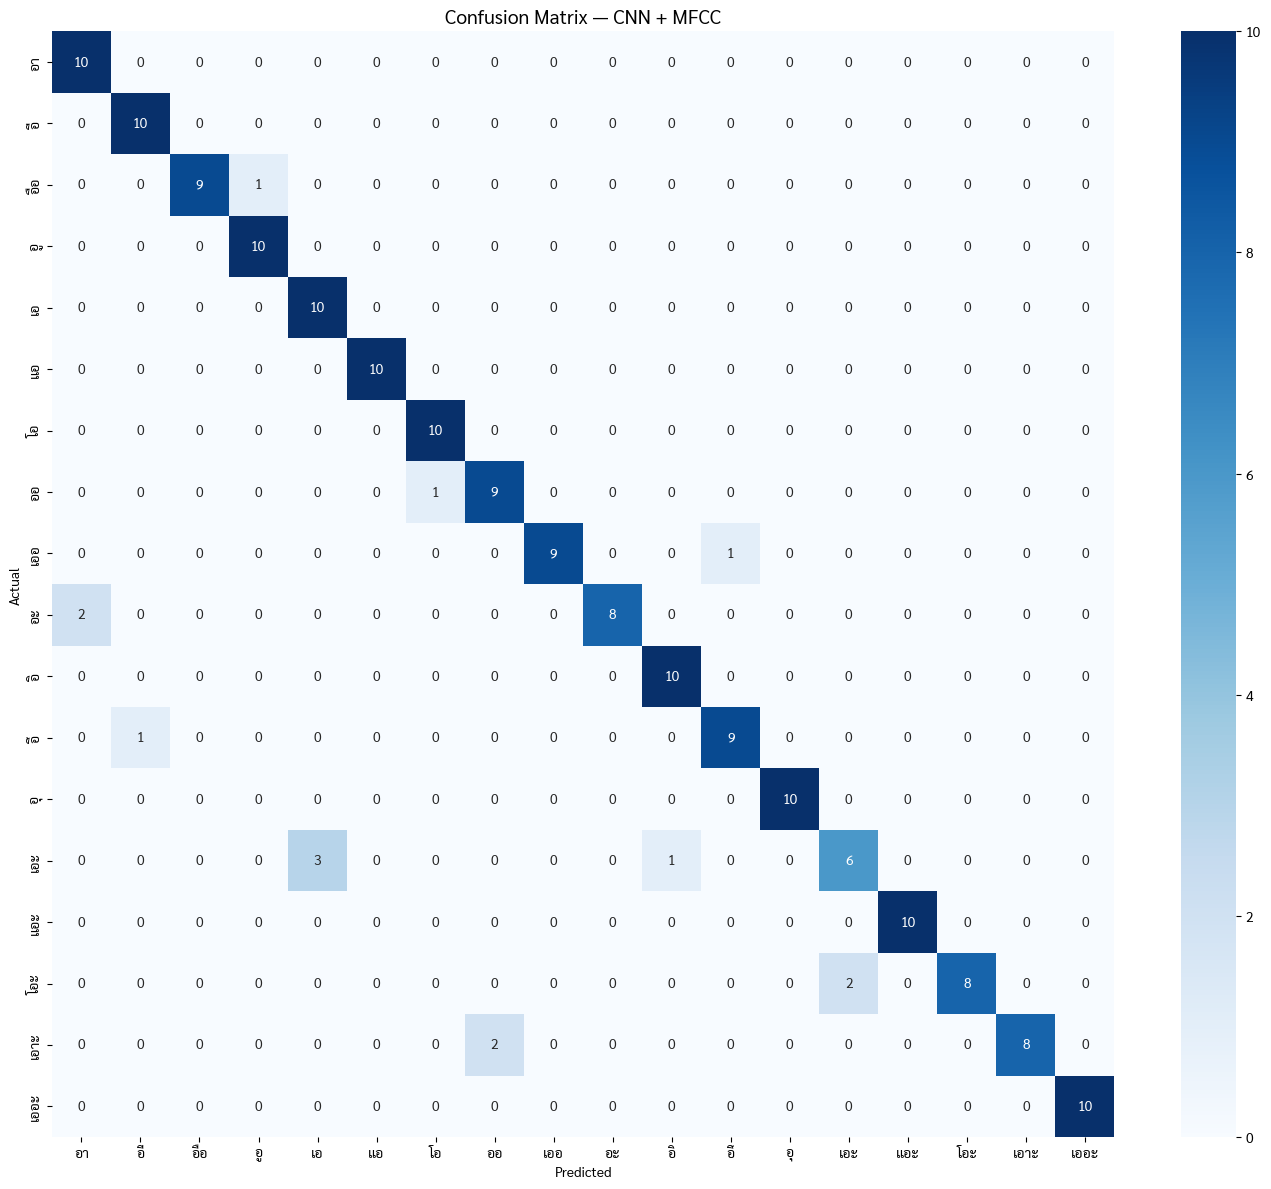

In [16]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=VOWEL_LABELS, yticklabels=VOWEL_LABELS)
plt.title('Confusion Matrix — CNN + MFCC', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_cnn_mfcc_cm.png', dpi=150)
plt.show()

## Section 13 — Training Curve

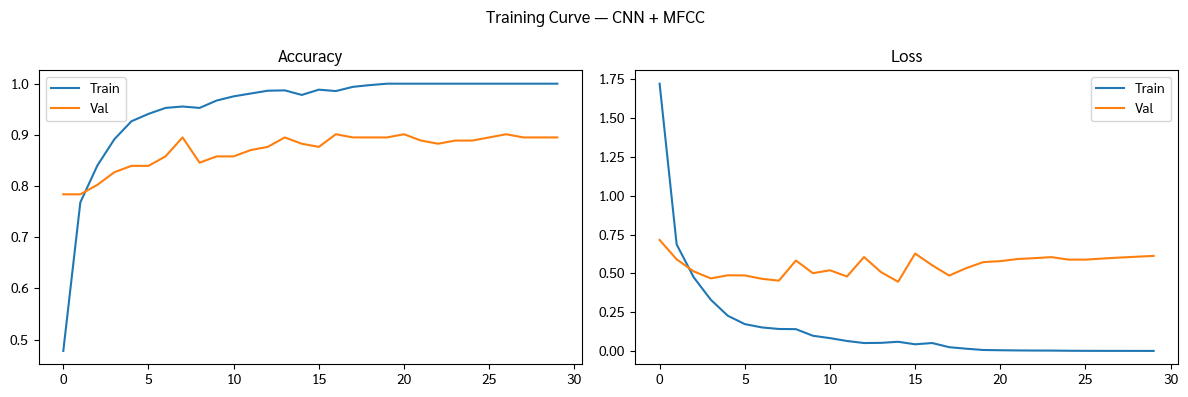

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('Training Curve — CNN + MFCC')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_cnn_mfcc_curve.png', dpi=150)
plt.show()

## Section 14 — Save Model & Results

In [18]:
print('\n── For comparison table ──')
print(f"CNN + MFCC | CV F1: {df_folds['val_f1_macro'].mean():.4f}±{df_folds['val_f1_macro'].std():.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc*100:.2f}%")


── For comparison table ──
CNN + MFCC | CV F1: 0.8650±0.0207 | Test F1: 0.9207 | Test Acc: 92.22%
